In [5]:
import torch
import torch.nn as nn

import tiktoken

In [6]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,   # Vocabulary size
    "context_length": 256, # Shortened context length (orig: 1024)
    "emb_dim": 768,        # Embedding dimension
    "n_heads": 12,         # Number of attention heads
    "n_layers": 12,        # Number of layers
    "drop_rate": 0.1,      # Dropout rate
    "qkv_bias": False      # Query-key-value bias
}

In [7]:
# -- Attention sub-components
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (
            1 + torch.tanh(
                torch.sqrt(torch.tensor(2.0 / torch.pi)) * 
                (x + 0.044715 * torch.pow(x, 3))
                )
        )


class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"])
        )

    def forward(self, x):
        return self.layers(x)


class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.emb_dim = emb_dim
        self.eps = 1e-5

        # Trainable Params that LLM adjusts during training
        # Allows model to learn appropriat scaling and shifting
        # that best suits the data processing
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

# --- Attention mechanisms
class CausalAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, qkv_bias=False):
        super().__init__()
        self.d_out = d_out
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

        self.dropout = nn.Dropout(p=dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape   # (batch_size, seq_length, embedding_dim)
        keys = self.W_key(x)             # (batch_size, seq_length, d_out)
        queries = self.W_query(x)        # (batch_size, seq_length, d_out)
        values = self.W_value(x)         # (batch_size, seq_length, d_out)

        # Compute attention scores
        attn_scores = queries @ keys.transpose(1, 2)  # (batch_size, seq_length, seq_length)
        attn_scores.masked_fill_(
            self.mask.bool()[:num_tokens, :num_tokens], -torch.inf)

        # Compute attention weights with softmax
        attn_weights = torch.softmax(attn_scores / self.d_out**0.5, dim=-1)

        # Apply dropout to the attention weights
        attn_weights = self.dropout(attn_weights)

        context_vec = attn_weights @ values  # (batch_size, seq_length, d_out)
        return context_vec


class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads  # Reduce proj. dim to match desired output dim

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

        self.out_proj = nn.Linear(d_out, d_out)  # Linear lay layer to combine heads
        self.dropout = nn.Dropout(p=dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape   # (batch_size, seq_length, embedding_dim)

        keys = self.W_key(x)             # (batch_size, seq_length, d_out)
        queries = self.W_query(x)        # (batch_size, seq_length, d_out)
        values = self.W_value(x)         # (batch_size, seq_length, d_out)

        # Implicitly split matrix by adding num_heads dimension
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)

        # Transpose (b, num_tokens, num_heads, head_dim) to (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        # Compute dot product for each attention head
        attn_scores = queries @ keys.transpose(2, 3)

        # Mask truncated to number of tokens..?
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        context_vec = (attn_weights @ values).transpose(1, 2)   # (b, num_tokens, num_heads, head_dim)

        # Combine heads, self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.contiguous().view(
            b, num_tokens, self.d_out
        )
        context_vec = self.out_proj(context_vec)
        return context_vec


# --- Transformer block
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.atn = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"]
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.dropout_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        shortcut = x
        x = self.norm1(x)
        x = self.atn(x)
        x = self.dropout_shortcut(x)
        x = x + shortcut

        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.dropout_shortcut(x)

        return x + shortcut

# -- GPT model
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        # Transformer blocks
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )

        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)

        pos_embeds = self.pos_emb(
            torch.arange(seq_len, device=in_idx.device)
        )

        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

In [10]:
# torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)

In [11]:
# -- Utilities
def generate_text_simple(model, idx, max_new_tokens, context_size):
    # idx is a (batch, n_tokens) array of indices in the current context

    for _ in range(max_new_tokens):
        # Crops current context if it exceeds the supported context size.
        # I.e if LLM supports only 5 tokens, and context size is 10,
        # then only last 5 tokens are used as context.
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)

        # Focus only on the last time step so that
        # (batch, n_token, vocab_size) becomes (batch, vocab_size)
        logits = logits[:, -1, :]

        # probas has shape (batch, vocab_size)
        # NOTE: softmax is monotonic (i.e preserves order of inputs when transformed to outputs)
        # In practice could use torch.argmax
        probas = torch.softmax(logits, dim=-1)

        # idx_next has shape (batch, 1)
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)

        # Appends sampled index to next running sequence, where idx shape (batch, n_tokens+1)
        idx = torch.cat((idx, idx_next), dim=1)

    return idx

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)
    return tokenizer.decode(flat.tolist())


start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you 318 wiret Drugaos Antar BO mand owing brightellation


### Calculating text generation loss
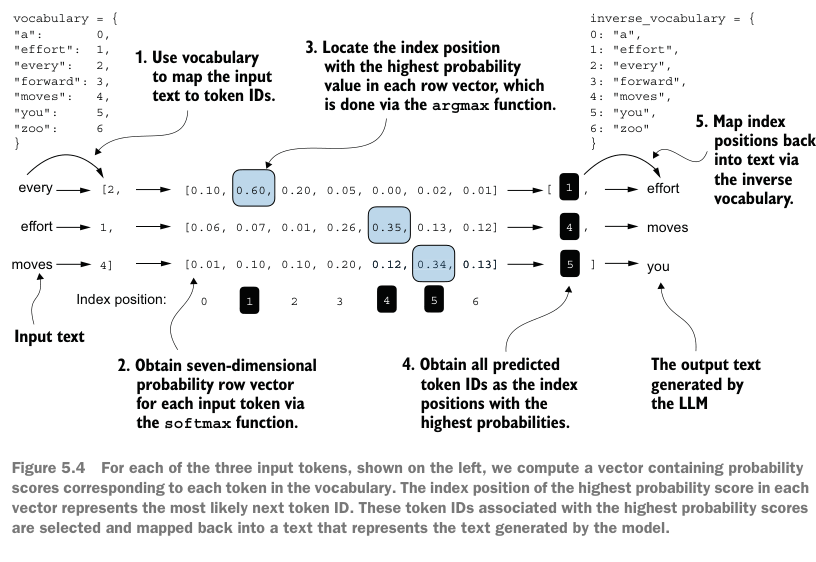

In [12]:
inputs = torch.tensor([[16833, 3626, 6100],   # ["every effort moves",
                       [40,    1107, 588]])   #  "I really like"]

targets = torch.tensor([[3626, 6100, 345  ],  # [" effort moves you",
                        [1107,  588, 11311]]) #  " really like chocolate"]

In [14]:
# Disable gradient trakcing since we are not training yet
with torch.no_grad():
    logits = model(inputs)

# Probability of each token in vocab
probas = torch.softmax(logits, dim=-1)
print(probas.shape)     # (batch_size, number of tokens in each input, embedding dimensionality)

torch.Size([2, 3, 50257])


In [16]:
token_ids = torch.argmax(probas, dim=-1, keepdim=True)
print("Token IDs:\n", token_ids)


# Convert tokens back to text
print(f"Targets batch 1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Outputs batch 1: {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

Token IDs:
 tensor([[[47917],
         [23325],
         [49805]],

        [[ 3210],
         [30613],
         [38027]]])
Targets batch 1:  effort moves you
Outputs batch 1: ategic travelersointment


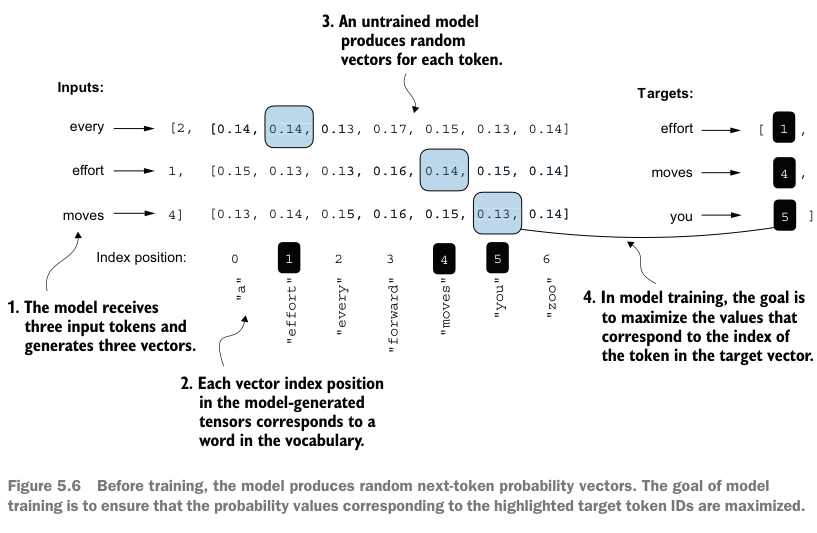

In [18]:
# Computing initial softmax probabilty scores corresponding to target tokens
text_idx = 0
target_probas_1 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 1:", target_probas_1)

text_idx = 1
target_probas_2 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 2:", target_probas_2)

Text 1: tensor([8.4795e-06, 2.0041e-05, 1.7530e-05])
Text 2: tensor([1.4351e-05, 4.2792e-05, 1.5319e-05])


Goal of training LLM is to maximize likelihood of the correct token by increasing probability relative to other tokens

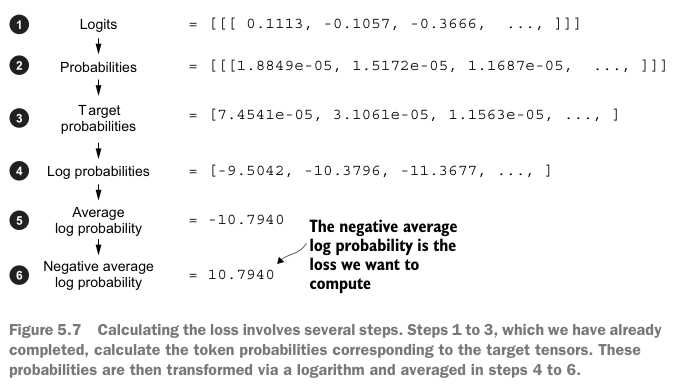

In [20]:
# Working with log probs more manageable in mathematical optimziation
# than compared handling scores directly (appendix B)
log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))
print(log_probas)

avg_log_probas = torch.mean(log_probas)
print(avg_log_probas)

tensor([-11.6779, -10.8177, -10.9516, -11.1517, -10.0592, -11.0864])
tensor(-10.9574)


Goal is to get avg log prob to as close to 0 by updating model weights
- In deep learning, bring negative avg log prob down to 0
- Negative avg log prob is avg_log_prob * -1
- Turning this negative value to positive is known as cross entropy loss

Cross entropy loss:
- Measures the difference between two probability distributions
    - true distribution of labels
    - predicted distribution from model

In [ ]:
# This is also known as cross-entropy loss
neg_avg_log_probas = avg_log_probas * -1
print(neg_avg_log_probas)

tensor(10.9574)


In [24]:
print("Logits shape:", logits.shape)        # (batch_size, number of tokens, vocab_size)
print("Targets shape:", targets.shape)      # (batch_size, number of tokens)

Logits shape: torch.Size([2, 3, 50257])
Targets shape: torch.Size([2, 3])


In [25]:
# We want to flatten these tensors by combining over batch dimension for cross entropy
logits_flat = logits.flatten(0, 1)
targets_flat = targets.flatten()
print("Flattened logits:", logits_flat.shape)
print("Flattened targets:", targets_flat.shape)

Flattened logits: torch.Size([6, 50257])
Flattened targets: torch.Size([6])


In [26]:
loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print(loss)

tensor(10.9574)


##### Perplexity
Measure often alongside cross entropy loss. Provide more interpretable way to understand uncertainty of a model in predicting the next token in a sequence.
- Lower perplexity indicates model predictions closer to actual distribution

In [28]:
# Perplexity
perplexity = torch.exp(loss)
print(perplexity)

tensor(57377.6328)


#### Calculating training/validation set losses

In [ ]:
# -- Get the verdict training data
import os
import requests

file_path = "the-verdict.txt"
url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt"

if not os.path.exists(file_path):
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    text_data = response.text
    with open(file_path, "w", encoding="utf-8") as file:
        file.write(text_data)
else:
    with open(file_path, "r", encoding="utf-8") as file:
        text_data = file.read()


In [32]:
# First 99 characters
print(text_data[:99])

# Last 99 characters
print(text_data[-99:])

total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))

print("Characters:", total_characters)
print("Tokens:", total_tokens)

I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 
it for me! The Strouds stand alone, and happen once--but there's no exterminating our kind of art."
Characters: 20479
Tokens: 5145


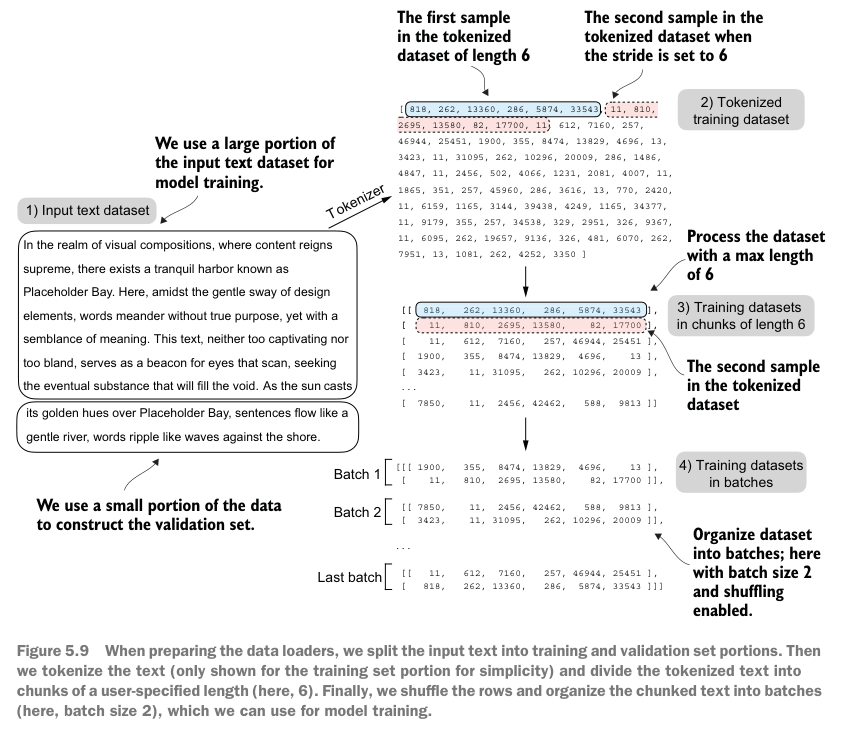

In [34]:
import torch
from torch.utils.data import Dataset, DataLoader
import tiktoken


class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.tokenizer = tokenizer
        self.input_ids = []
        self.target_ids = []

        # Tokenize the entire text
        token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})

        # Use a sliding window to chunk the book into overlapping sequences of max_length
        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i + max_length]
            target_chunk = token_ids[i + 1: i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]

def create_dataloader_v1(txt, batch_size=4, max_length=256,
                         stride=128, shuffle=True, drop_last=True, num_workers=0):

    # Initialize the tokenizer
    tokenizer = tiktoken.get_encoding("gpt2")

    # Create dataset
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

    # Create dataloader
    dataloader = DataLoader(
        dataset, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last, num_workers=num_workers)

    return dataloader

In [ ]:
# Train/validation ratio
train_ratio = 0.9
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

# Train/Validation loaders
torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)